## Testing at low $L^A_{eff}$

In [1]:
# ================================
# eLoss-only notebook (pub styling)
# ================================
import numpy as np, matplotlib.pyplot as plt
import sys, os
from dataclasses import replace
sys.path.append("../code")

# --- imports & knobs ---
from particle import Particle
from glauber  import SystemSpec, OpticalGlauber
from coupling import alpha_s_provider
from cross_sections import SigmaPPTable, L_eff_minbias  
import quenching_fast as QF
from quenching_fast import QuenchParams, TorchSigmaPPTable
import quenching_fast_parts as qfp

In [2]:
# --------- Setup (tables, Glauber, params) ----------
device   = "cuda"   # fine; σpp sampling is CPU-safe now
roots5, roots8 = 5023.0, 8160.0
sigma_nn_5, sigma_nn_8 = 67.6, 71.0
A = 208
# particles
P_charmonia = Particle(family="charmonia",  state="avg")
P_bottomonia = Particle(family="bottomonia", state="avg")

# pp table grid (densify 4–12 GeV to smooth R(pT) )
y_tab  = np.linspace(-5, 5, 41)
pt_tab = np.unique(np.concatenate([np.linspace(0,4,41), np.linspace(4,12,161), np.linspace(12,25,131)]))

# choose αs (constant for AP)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.5)

In [3]:
# --- 1) σ_pp tables (build once per species/energy)
Y_GRID = np.linspace(-5.5, 5.5, 241)
PT_GRID = np.linspace(0.0, 30.0, 301)
# Torch pp tables if torch is available (fast), else you can skip and the module uses P.d2sigma_pp directly
try:
    TAB_chi_5  = QF.TorchSigmaPPTable(P_charmonia, roots5, Y_GRID, PT_GRID, device=device)
    TAB_chi_8  = QF.TorchSigmaPPTable(P_charmonia, roots8, Y_GRID, PT_GRID, device=device)
    TAB_ups_5  = QF.TorchSigmaPPTable(P_bottomonia, roots5, Y_GRID, PT_GRID, device=device)
    TAB_ups_8  = QF.TorchSigmaPPTable(P_bottomonia, roots8, Y_GRID, PT_GRID, device=device)
except Exception:
    TAB_chi_5 = TAB_chi_8 = TAB_ups_5 = TAB_ups_8 = None  # falls back to NumPy path

# Glauber systems (for centrality & L_eff)
gl5 = OpticalGlauber(SystemSpec("pA", roots5, A=A, sigma_nn_mb=sigma_nn_5))
gl8 = OpticalGlauber(SystemSpec("pA", roots8, A=A, sigma_nn_mb=sigma_nn_8))
Lmb_5 = gl5.leff_minbias_pA() if hasattr(gl5, "leff_minbias_pA") else gl5.leff_minbias("pA")
Lmb_8 = gl8.leff_minbias_pA() if hasattr(gl8, "leff_minbias_pA") else gl8.leff_minbias("pA")

cent_bins = [(60,100)]

Leff_5  = gl5.leff_bins_pA(cent_bins, method="optical") # or "binomial"
Leff_5["0-100%"] = Lmb_5
Leff_8  = gl8.leff_bins_pA(cent_bins, method="optical")  # or "binomial"
Leff_8["0-100%"] = Lmb_8
print("L_eff (5 TeV pPb): ", Leff_5)
print("L_eff (8 TeV pPb): ", Leff_8)

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7724.42 mb, σ_tot^pA ≈ 1911.63 mb
[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
L_eff (5 TeV pPb):  {'60-100%': 4.03694495872482, '0-100%': 10.414158247314315}
L_eff (8 TeV pPb):  {'60-100%': 3.9743559896185685, '0-100%': 10.414158247314315}


In [4]:
# 1) Build σ_pp table (same grids you use elsewhere)
table = TorchSigmaPPTable(P_bottomonia, roots_GeV=8160.0,
                          y_grid=np.linspace(-6, 6, 241),
                          pt_grid=np.linspace(0.0, 40.0, 801))

In [5]:
QP5 = QF.QuenchParams(qhat0=0.075, lp_fm=1.5, LA_fm=Lmb_5, LB_fm=Lmb_5,
                     lambdaQCD=0.25, roots_GeV=roots5,
                     alpha_of_mu=alpha_cst, alpha_scale="mT",
                     mapping="exp", device=device)

QP8 = replace(QP5, roots_GeV=roots8, LA_fm=Lmb_8, LB_fm=Lmb_8)

In [6]:
Rl, Rb, Rf = qfp.R_factored_pA(
    P=P_bottomonia, roots_GeV=roots8, qp=QP8,
    y=1.5, pT=6.0, table_or_callable=TAB_ups_8,
    Ny=None, Nphi=32, mapping="exp", use_torch=True
)
print("R_loss, R_broad, R_both =", Rl, Rb, Rf)

R_loss, R_broad, R_both = 1.002476581527197 1.0471625209239936 1.049755904279287


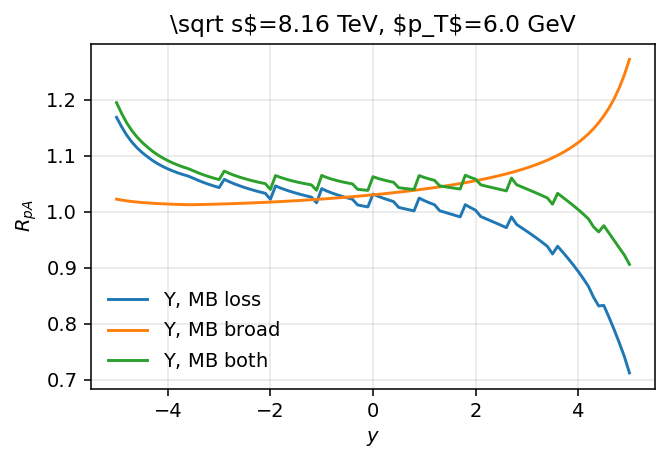

In [7]:
y_grid = np.linspace(-5, 5, 101)
p_fix  = 6.0

Rl_y, Rb_y, Rf_y = qfp.parts_vs_y(
    P=P_bottomonia, roots_GeV=roots8, qp=QP8,
    table_or_callable=TAB_ups_8, y_grid=y_grid, pT=p_fix,
    Ny_loss=200, Nphi_broad=50, mapping="exp", use_torch=True
)

fig, ax = plt.subplots(1,1, figsize=(5.2,3.2), dpi=140)
qfp.quick_plot_parts_vs_y(ax, y_grid, Rl_y, Rb_y, Rf_y, label_prefix=r"$\Upsilon$, MB")
ax.set_title(rf"\sqrt s$=8.16 TeV, $p_T$={p_fix:.1f} GeV")
ax.grid(alpha=0.3); ax.legend(frameon=False); plt.show()

In [8]:
y_fix  = 1.5
p_grid = np.linspace(0.0, 20.0, 160)

Rl_p, Rb_p, Rf_p = qfp.parts_vs_pT(
    P=P_bottomonia, roots_GeV=roots8, qp=QP8,
    table_or_callable=sigma_nn_8, p_grid=p_grid, y=y_fix,
    Ny_loss=None, Nphi_broad=32, mapping="exp", use_torch=True
)

fig, ax = plt.subplots(1,1, figsize=(5.2,3.2), dpi=130)
ax.plot(p_grid, Rl_p,  lw=1.6, label="loss")
ax.plot(p_grid, Rb_p,  lw=1.6, label="broad")
ax.plot(p_grid, Rf_p,  lw=1.6, label="both")
ax.set_xlabel(r"$p_T$ [GeV]"); ax.set_ylabel(r"$R_{pA}$")
ax.set_title(rf"$\sqrt s=8.16$ TeV, $y={y_fix:.2f}$")
ax.legend(frameon=False); plt.show()

TypeError: Got a scalar (e.g. sigma_nn) where a pp double-differential cross-section is required. Pass TorchSigmaPPTable or a callable σ_pp(y,pT[,roots]).

In [ ]:
y_grid = np.linspace(-4.5, 4.5, 73)
p_fix  = 6.0

Rl_y, Rb_y, Rf_y = qfp.parts_vs_y(
    P=P_bottomonia, roots_GeV=roots8, qp=QP8,
    table_or_callable=sigma_nn_8, y_grid=y_grid, pT=p_fix,
    Ny_loss=None, Nphi_broad=32, mapping="exp", use_torch=True
)

fig, ax = plt.subplots(1,1, figsize=(5.2,3.2), dpi=130)
ax.plot(y_grid, Rl_y, lw=1.6, label="loss")
ax.plot(y_grid, Rb_y, lw=1.6, label="broad")
ax.plot(y_grid, Rf_y, lw=1.6, label="both")
ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$R_{pA}$")
ax.set_title(rf"$\sqrt s=8.16$ TeV, $p_T={p_fix:.1f}$ GeV")
ax.legend(frameon=False); plt.show()

TypeError: Got a scalar (e.g. sigma_nn) where a pp double-differential cross-section is required. Pass TorchSigmaPPTable or a callable σ_pp(y,pT[,roots]).

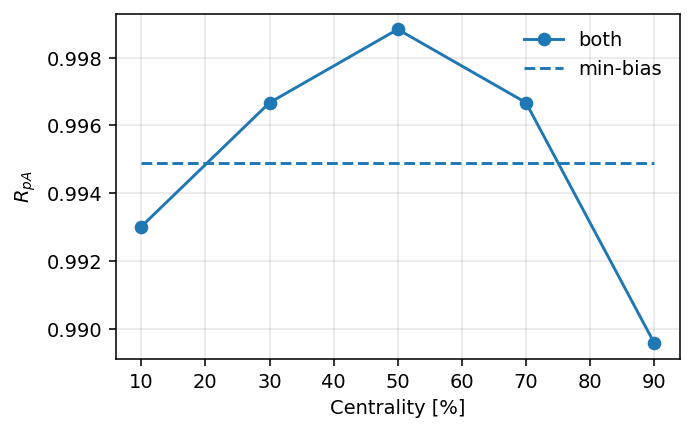

In [ ]:
cent_bins = [0,20,40,60,80,100]

resC = qfp.rpa_parts_centrality_binned(
    P=P_bottomonia, roots_GeV=roots8, qp_base=QP8,
    table_or_callable=TAB_ups_8, glauber=gl8,
    cent_edges_or_bins=cent_bins,
    y_range=(1.0, 2.0), pt_range=(0.5, 12.0),
    Ny_bin=18, Npt_bin=36, weight_kind="auto",
    weight_ref_y=0.0, Ny_loss=100, Nphi_broad=24, mapping="exp", use_torch=True
)

# Plot R_both vs centrality + min-bias band
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize=(5.2,3.2), dpi=140)
ax.plot(resC["centers"], resC["R_fact"], marker="o", ls="-", label="both")
ax.hlines(resC["R_minbias_fact"], xmin=resC["centers"].min(), xmax=resC["centers"].max(),
          linestyles="--", label="min-bias")
ax.set_xlabel("Centrality [%]"); ax.set_ylabel(r"$R_{pA}$")
ax.grid(alpha=0.3); ax.legend(frameon=False); plt.show()
